Imports

In [7]:
import numpy as np

from matplotlib import pyplot as plt

A function to calculate transfer function of a moving average filter with length $L$ and order $K$.

In [8]:
def calc_tran_fun(L, N_omegas, K=1):
    omegas = np.linspace(-np.pi, np.pi, N_omegas)
    Hz = np.zeros(np.shape(omegas))
    for d in range(0, L):
        Hz = Hz + np.exp(-1j * omegas * d)
    Hz = Hz / L
    HzK = Hz
    for k in range(0, K - 1):
        HzK *= Hz
    return Hz

Add example plots for the transfer functions of higher-order filters.

/tmp/ipykernel_8583/3265993285.py:22: RuntimeWarning: divide by zero encountered in log10
  axes[k_idx, 1].plot(omegas, 20 * np.log10(np.abs(Hz_2)), label=r"Length = 2")
/tmp/ipykernel_8583/3265993285.py:24: RuntimeWarning: divide by zero encountered in log10
  axes[k_idx, 1].plot(omegas, 20 * np.log10(np.abs(Hz_10)), label=r"Length = 10")


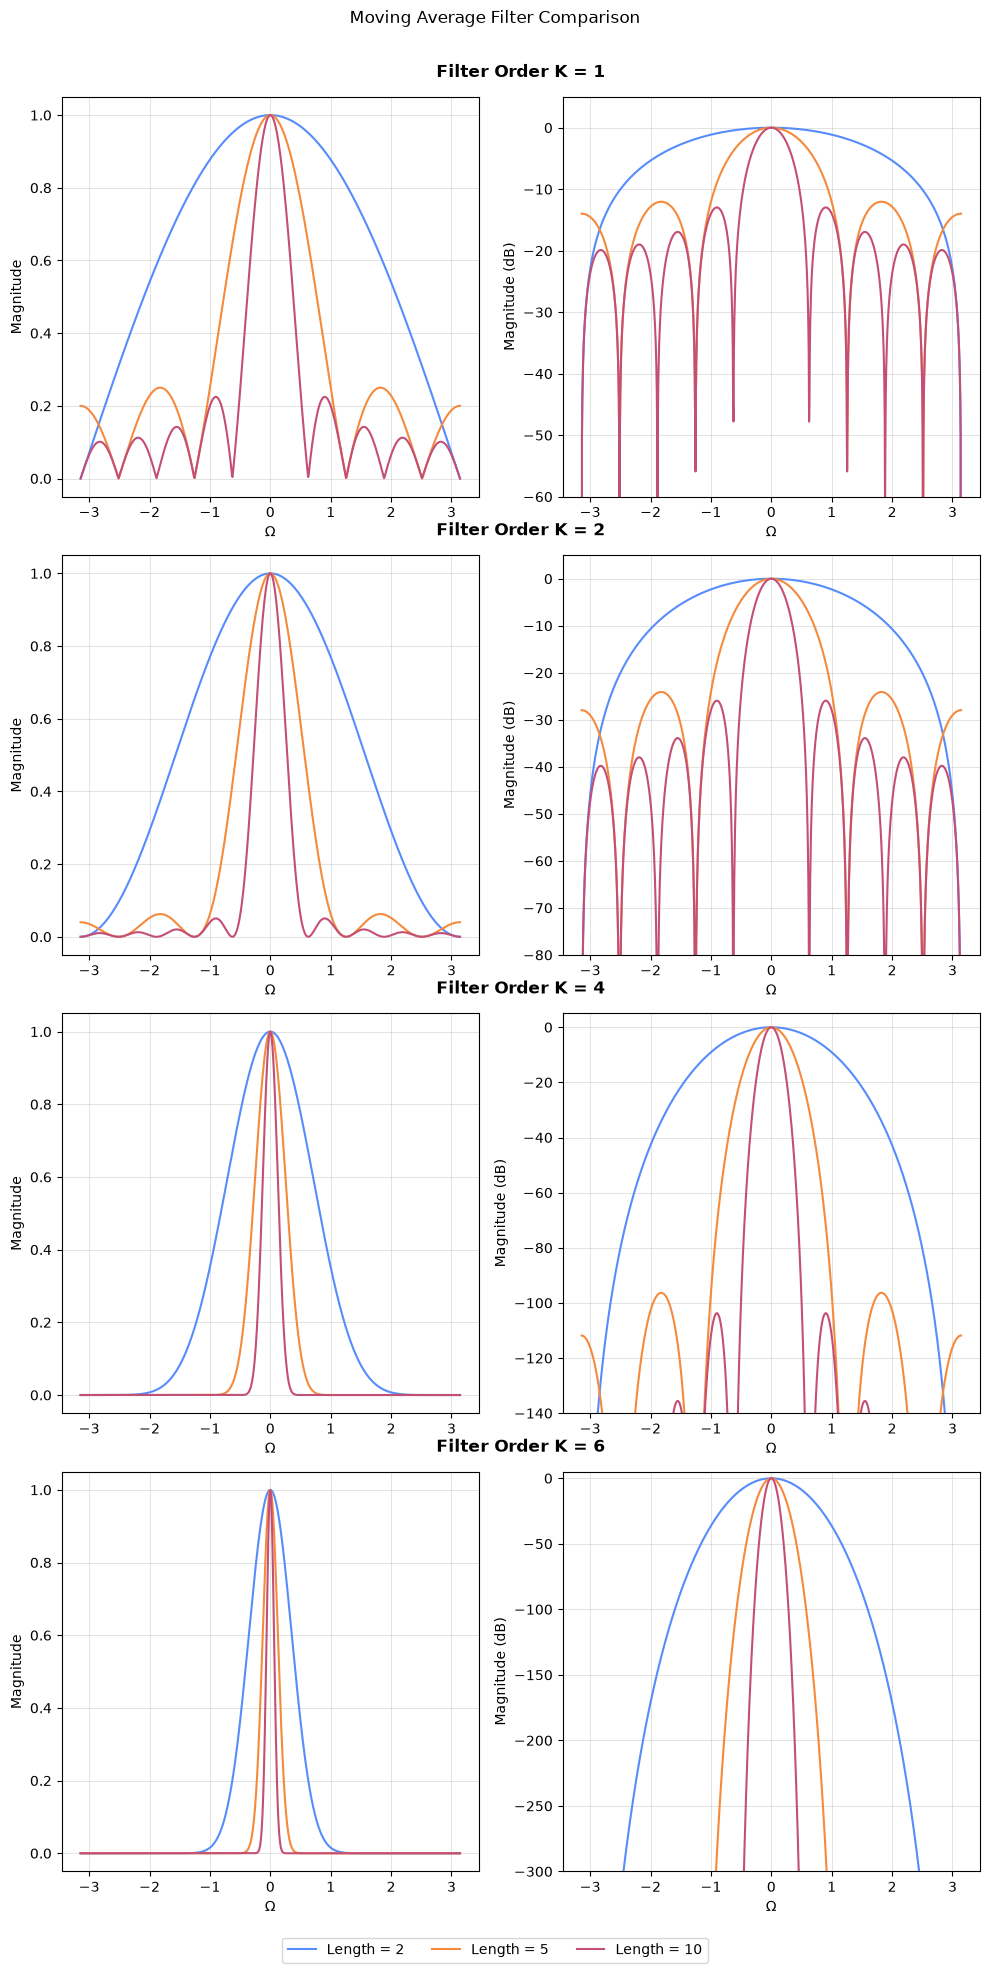

In [9]:
N_omegas = 1000

omegas = np.linspace(-np.pi, np.pi, N_omegas)

Ks = [1, 2, 4, 6]
y_min_vals = [-60, -80, -140, -300]

fig, axes = plt.subplots(len(Ks), 2, figsize=(10, 20))

for k_idx in range(0, len(Ks)):
    Hz_2 = calc_tran_fun(2, N_omegas, K=Ks[k_idx])
    Hz_5 = calc_tran_fun(5, N_omegas, K=Ks[k_idx])
    Hz_10 = calc_tran_fun(10, N_omegas, K=Ks[k_idx])

    axes[k_idx, 0].plot(omegas, np.abs(Hz_2), label=r"Length = 2")
    axes[k_idx, 0].plot(omegas, np.abs(Hz_5), label=r"Length = 5")
    axes[k_idx, 0].plot(omegas, np.abs(Hz_10), label=r"Length = 10")
    axes[k_idx, 0].set_xlabel(r"$\Omega$")
    axes[k_idx, 0].set_ylabel(r"Magnitude")
    axes[k_idx, 0].grid()

    axes[k_idx, 1].plot(omegas, 20 * np.log10(np.abs(Hz_2)), label=r"Length = 2")
    axes[k_idx, 1].plot(omegas, 20 * np.log10(np.abs(Hz_5)), label=r"Length = 5")
    axes[k_idx, 1].plot(omegas, 20 * np.log10(np.abs(Hz_10)), label=r"Length = 10")
    axes[k_idx, 1].set_xlabel(r"$\Omega$")
    axes[k_idx, 1].set_ylabel(r"Magnitude (dB)")
    axes[k_idx, 1].set_ylim([y_min_vals[k_idx], 5])
    axes[k_idx, 1].grid()

fig.suptitle("Moving Average Filter Comparison")

plt.tight_layout(rect=[0, 0.02, 1, 0.96])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0))

for k_idx in range(0, len(Ks)):
    pos_left = axes[k_idx, 0].get_position()
    pos_right = axes[k_idx, 1].get_position()
    fig.text(
        (pos_left.x0 + pos_right.x1) / 2,
        pos_left.y1 + 0.01,
        f"Filter Order K = {Ks[k_idx]}",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

plt.show()

Implementation of moving average filter using convolution.

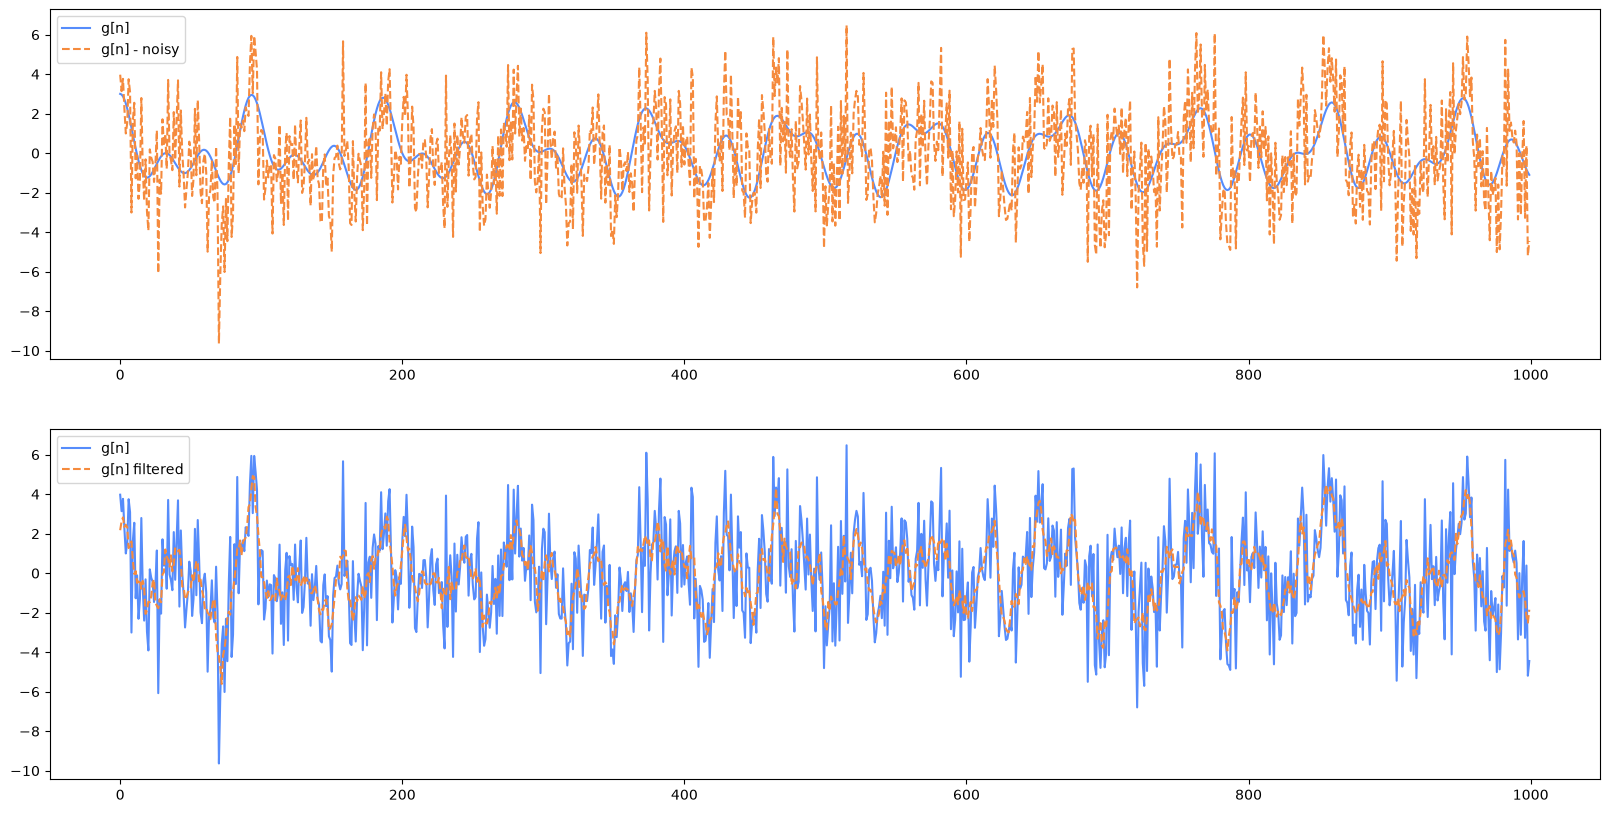

In [10]:
def calc_ma_coeffs(L):
    return np.ones(L) / L

N = 1e3
fs = 1e3
fks = np.array([10.5, 21.1, 32.5])
cks = np.ones(np.shape(fks))
n = np.arange(0, N)

L = 5
sigma = 2
h = calc_ma_coeffs(L)
gn = np.real(np.exp(-1j * 2 * np.pi * (n[:, None] / fs) @ fks[None, :]) @ cks)
gn_noisy = gn + sigma * np.random.randn(*gn.shape)

conv_out = np.convolve(gn_noisy, h, mode="same")

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

axes[0].plot(gn, label="g[n]")
axes[0].plot(gn_noisy, "--", label="g[n] - noisy")
axes[0].legend()

axes[1].plot(gn_noisy, label="g[n]")
axes[1].plot(conv_out, "--", label="g[n] filtered")
axes[1].legend()

plt.show()

Comparison between convolution and CIC implementation of a decimation filter and convolution of FIR filter followed by decimation.

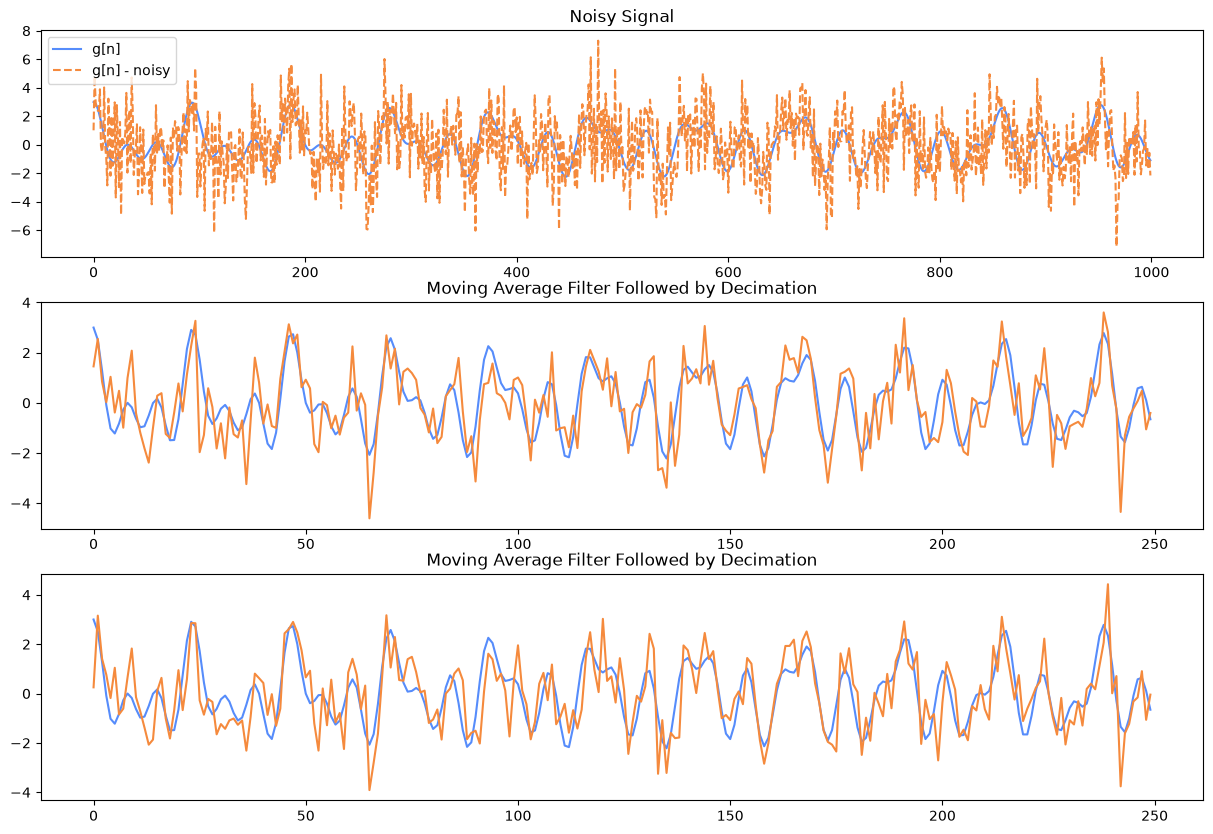

In [20]:
def run_CIC_decim_flt(x, M):
    # Integrator stage
    a = np.zeros(*gn.shape)
    x = x / M
    a[0] = x[0]

    for n_idx in range(1, len(a)):
        a[n_idx] = a[n_idx - 1] + x[n_idx]

    a_down = a[::M]

    # Comb Stage
    y = np.zeros(*a_down.shape)
    y[0] = a_down[0]

    for n_idx in range(1, len(a_down)):
        y[n_idx] = a_down[n_idx] - a_down[n_idx - 1]

    return y

N = 1e3
fs = 1e3
M = 4 # Decimation factor
fks = np.array([10.5, 21.1, 32.5])
cks = np.ones(np.shape(fks))
n = np.arange(0, N)

L = 4
sigma = 2
h = calc_ma_coeffs(L)
gn = np.real(np.exp(-1j * 2 * np.pi * (n[:, None] / fs) @ fks[None, :]) @ cks)
gn_noisy = gn + sigma * np.random.randn(*gn.shape)

gn_ma_conv = np.convolve(gn_noisy, h, mode="same")
gn_ma_conv = gn_ma_conv[::M]

yn_CIC = run_CIC_decim_flt(gn_noisy, M)

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(gn, label="g[n]")
axes[0].plot(gn_noisy, "--", label="g[n] - noisy")
axes[0].legend()
axes[0].set_title("Noisy Signal")

axes[1].plot(gn[::M], label="g[n]")
axes[1].plot(gn_ma_conv, label="g[n] - moving average")
axes[1].set_title("Moving Average Filter Followed by Decimation")

axes[2].plot(gn[::M], label="g[n]")
axes[2].plot(yn_CIC, label="g[n] - CIC")
axes[2].set_title("Moving Average Filter Followed by Decimation")

plt.show()

CIC Interpolation Filter - the goal is to go from lower sampling rates to higher ones